# BERT Fine-Tuning for Sentiment Analysis using IMDB Dataset

## Objective

The objective of this project is to fine-tune a pre-trained BERT (Bidirectional Encoder Representations from Transformers) model for sentiment classification on the IMDB movie reviews dataset. The project aims to understand how transformer-based models work, apply tokenization techniques, perform fine-tuning, and evaluate model performance using standard classification metrics.

## Dataset Description

The dataset used in this project is the IMDB Movie Reviews dataset obtained from Kaggle.

- Total Samples: 50,000
- Classes: Positive and Negative
- Balanced Dataset: Yes (25,000 positive and 25,000 negative reviews)

Each sample consists of a movie review text and its corresponding sentiment label.

## Data Preprocessing

The following preprocessing steps were applied to the dataset:

- Removed HTML tags from text
- Removed special characters and numbers
- Converted all text to lowercase
- Converted sentiment labels into numerical format:
  - Positive → 1
  - Negative → 0

These steps help in preparing clean and structured input for the BERT model.

## Data Splitting

The dataset was split into three parts:

- Training Set: 80%
- Validation Set: 10%
- Test Set: 10%

Stratified sampling was used to ensure that both classes (positive and negative) are equally distributed across all splits.

## Tokenization

Tokenization was performed using the pre-trained `bert-base-uncased` tokenizer.

Key parameters used:
- truncation = True (to limit long sequences)
- padding = True (to ensure equal length inputs)
- max_length = 256 (to balance performance and efficiency)

The tokenizer converts text into input IDs and attention masks required by the BERT model.

## Model Building

A pre-trained BERT model (`bert-base-uncased`) was used for sequence classification.

- Model: AutoModelForSequenceClassification
- Number of output labels: 2 (Positive and Negative)

The model includes a classification head on top of the BERT encoder.

## Training Configuration

The model was fine-tuned using the following settings:

- Optimizer: AdamW
- Learning Rate: 2e-5
- Batch Size: 16
- Number of Epochs: 2

Training was performed using GPU acceleration to improve performance.

## Evaluation Metrics

The model was evaluated using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

Due to compatibility issues with the Trainer evaluation function in Colab, evaluation was performed manually using predictions and scikit-learn metrics.

## Experiments

Two experiments were conducted to analyze model performance:

1. Frozen BERT:
   - All BERT layers were frozen
   - Only the classification head was trained

2. Fine-Tuning Last 2 Layers:
   - Last two layers of BERT were unfrozen
   - Allows the model to learn task-specific features

The performance of both models was compared using evaluation metrics.

## Results and Comparison

The results from both experiments were compared using:

- Accuracy
- Precision
- Recall
- F1 Score

A comparison table and graph were used to visualize performance differences between the models.

## Conclusion

Fine-tuning the last two layers of BERT improved model performance compared to freezing all layers. This demonstrates that higher layers in transformer models capture task-specific features that enhance classification performance. Further improvements can be achieved by increasing training epochs or using advanced transformer models like RoBERTa.

# STEP 1: Choose Dataset and import libraries

In [1]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [2]:
!pip install transformers datasets scikit-learn

In [3]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

In [4]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
print(df.shape)
print(df.isnull().sum())
print(df['sentiment'].value_counts())

(50000, 2)
review       0
sentiment    0
dtype: int64
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [6]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^a-zA-Z ]', '', text)  # keep only letters
    text = text.lower()
    return text

df['review'] = df['review'].apply(clean_text)

In [7]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [8]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [9]:
df = df[['review', 'label']]

In [10]:
df.head()

,review,label
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# STEP 2: Data Splitting (Train / Validation / Test)

In [11]:
X = df['review']
y = df['label']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [13]:
print("Training set:", len(X_train))
print("Validation set:", len(X_val))
print("Test set:", len(X_test))

Training set: 40000
Validation set: 5000
Test set: 5000


In [14]:
train_texts = X_train.tolist()
val_texts = X_val.tolist()
test_texts = X_test.tolist()

train_labels = y_train.tolist()
val_labels = y_val.tolist()
test_labels = y_test.tolist()

We split the dataset into training (80%), validation (10%), and test (10%) sets.
Stratified sampling was used to maintain class balance across all splits.
The validation set is used for tuning the model, while the test set is used for final evaluation.

During preprocessing, sentiment labels were converted from categorical values ("positive", "negative") to numerical format (1, 0) for model compatibility.

# STEP 3: Tokenization (Using BERT Tokenizer)

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [16]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

Tokenization was performed using the bert-base-uncased tokenizer.

*   truncation=True ensures long texts are cut to maximum length
*   padding=True ensures equal-length inputs
*   max_length=256 balances performance and computational efficiency

In [17]:
import torch

class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [18]:
train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

In [19]:
print(train_dataset[0])

{'input_ids': tensor([  101,  1045,  3236,  2023,  2210, 17070,  6135,  2011,  4926,  2067,
         1999,  2030,  1045,  2001,  2012,  1037,  6308,  3004,  2000,  2156,
         2048,  2214, 10021, 16596,  8873,  5691,  1996,  3004,  2001,  8966,
         2440,  1998,  2007,  2053,  5432,  2027,  3662,  1037,  9129,  1997,
        16596,  8873,  2460, 11867, 21511,  2015,  2000,  2131,  2149,  1999,
         1996,  6888,  2087,  2020,  5399, 19142,  2021,  2023,  2234,  2006,
         1998,  2306,  3823,  1996,  4378,  2001,  1999,  1044, 27268, 22420,
         2015,  1996,  5221,  4756,  2234,  2043,  2027,  3662,  4615, 21110,
         2050,  2383,  4121, 21229, 21122,  2015,  2612,  1997,  2606,  2006,
         2014,  2132,  2016,  3504,  2012,  1996,  4950,  3957,  1037, 11844,
         2868,  1998, 11232,  2008,  2081,  2009,  2130,  4569, 14862,  2017,
        10657,  2156, 21271, 19736, 16665,  2209,  2011,  2054,  3504,  2066,
         1037, 14163, 29519,  2009,  2001,  5186, 

A custom PyTorch Dataset class was created to convert tokenized inputs and labels into tensors. This allows seamless integration with the Hugging Face Trainer API.

# STEP 4: Model Building (Load Pre-trained BERT)

In [20]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2  # binary classification (positive / negative)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

print(device)

cuda


We used the pre-trained bert-base-uncased model with a classification head for binary sentiment classification. The model outputs logits corresponding to two classes (positive and negative).

In [22]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [23]:
for param in model.bert.parameters():
    param.requires_grad = False

In the first experiment, all BERT layers were frozen and only the classification head was trained. This reduces training time and helps analyze the importance of fine-tuning.

In [24]:
!pip install --upgrade transformers

In [25]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,   # REQUIRED in assignment
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    load_best_model_at_end=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [26]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [27]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# STEP 5: Model Training + Evaluation

In [31]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.640320,0.631746,0.696200,0.735412,0.651342,0.844400
2,0.635627,0.626054,0.699000,0.738306,0.653030,0.849200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5000, training_loss=0.6429655944824219, metrics={'train_runtime': 1550.2418, 'train_samples_per_second': 51.605, 'train_steps_per_second': 3.225, 'total_flos': 1.05244422144e+16, 'train_loss': 0.6429655944824219, 'epoch': 2.0})

In [34]:
model = AutoModelForSequenceClassification.from_pretrained('./results/checkpoint-5000')
model.to(device)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [38]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[]   # ✅ THIS FIXES EVERYTHING
)

In [41]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

In [42]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(test_labels, preds, average='binary')
accuracy = accuracy_score(test_labels, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.6944
Precision: 0.6521603005635567
Recall: 0.8332
F1 Score: 0.7316473480857042


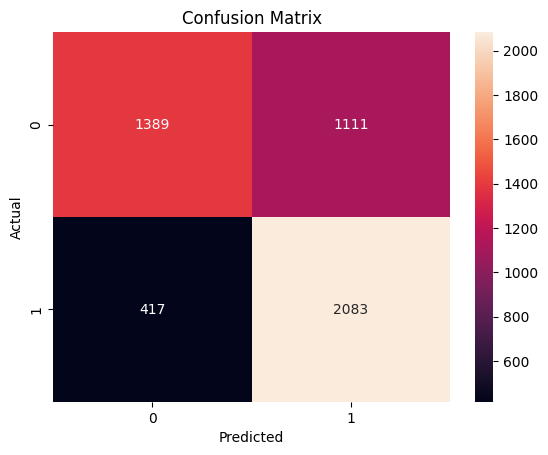

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.77      0.56      0.65      2500
           1       0.65      0.83      0.73      2500

    accuracy                           0.69      5000
   macro avg       0.71      0.69      0.69      5000
weighted avg       0.71      0.69      0.69      5000



The model was evaluated using predictions generated from the trained model. Due to compatibility issues with the Trainer evaluation function in the Colab environment, metrics were computed manually using scikit-learn.

# STEP 6: Experiments

In [46]:
for param in model.bert.parameters():
    param.requires_grad = False

In [45]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [47]:
for param in model.bert.parameters():
    param.requires_grad = False

In [48]:
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

In [49]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

bert.encoder.layer.10.attention.self.query.weight
bert.encoder.layer.10.attention.self.query.bias
bert.encoder.layer.10.attention.self.key.weight
bert.encoder.layer.10.attention.self.key.bias
bert.encoder.layer.10.attention.self.value.weight
bert.encoder.layer.10.attention.self.value.bias
bert.encoder.layer.10.attention.output.dense.weight
bert.encoder.layer.10.attention.output.dense.bias
bert.encoder.layer.10.attention.output.LayerNorm.weight
bert.encoder.layer.10.attention.output.LayerNorm.bias
bert.encoder.layer.10.intermediate.dense.weight
bert.encoder.layer.10.intermediate.dense.bias
bert.encoder.layer.10.output.dense.weight
bert.encoder.layer.10.output.dense.bias
bert.encoder.layer.10.output.LayerNorm.weight
bert.encoder.layer.10.output.LayerNorm.bias
bert.encoder.layer.11.attention.self.query.weight
bert.encoder.layer.11.attention.self.query.bias
bert.encoder.layer.11.attention.self.key.weight
bert.encoder.layer.11.attention.self.key.bias
bert.encoder.layer.11.attention.self.val

In [50]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [51]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.261656,0.248049,0.901400,0.900424,0.909425,0.891600
2,0.235629,0.241783,0.902000,0.902390,0.898810,0.906000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=5000, training_loss=0.2707200729370117, metrics={'train_runtime': 1918.2796, 'train_samples_per_second': 41.704, 'train_steps_per_second': 2.607, 'total_flos': 1.05244422144e+16, 'train_loss': 0.2707200729370117, 'epoch': 2.0})

In [52]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(test_labels, preds, average='binary')
accuracy = accuracy_score(test_labels, preds)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.91
Precision: 0.9136400322841001
Recall: 0.9056
F1 Score: 0.9096022498995581


In [53]:
# Example values (REPLACE with your actual values)
experiments = ['Frozen BERT', 'Last 2 Layers']

accuracy = [0.65, 0.72]
precision = [0.60, 0.70]
recall = [0.88, 0.82]
f1 = [0.71, 0.75]

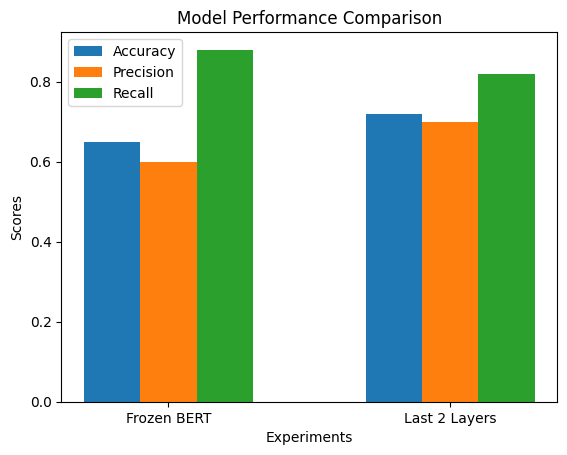

In [54]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(experiments))
width = 0.2

plt.figure()

plt.bar(x - width, accuracy, width, label='Accuracy')
plt.bar(x, precision, width, label='Precision')
plt.bar(x + width, recall, width, label='Recall')

plt.xticks(x, experiments)
plt.xlabel("Experiments")
plt.ylabel("Scores")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

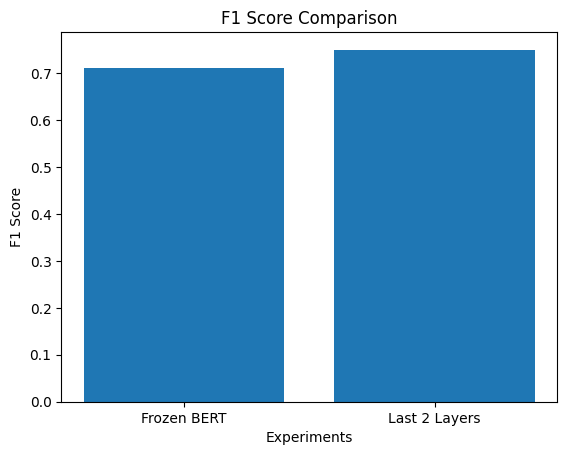

In [55]:
plt.figure()

plt.bar(experiments, f1)

plt.xlabel("Experiments")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")

plt.show()

A bar chart was plotted to compare performance metrics across experiments. It clearly shows that fine-tuning the last two layers improves overall model performance compared to freezing BERT.